In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/2020_Sep6_154k_hydrated_tweets.csv")

In [ ]:
# Before moving forward with a dataset:
# Confirm if country is not available
# Confirm if it was filtered on any search phrase
# Confirm if retweets are included, if yes, drop them
# Dropn NANs/impute as appropriate

In [ ]:
df[df.is_retweet == True]

,favorite_count,source,text,in_reply_to_screen_name,is_retweet,created_at,retweet_count,id_str


In [ ]:
df.tail()

,favorite_count,source,text,in_reply_to_screen_name,is_retweet,created_at,retweet_count,id_str
153749,1,Twitter for iPad,b'@theasscat I even get fooled sometimes. It\x...,theasscat,False,Mon Sep 07 04:03:13 +0000 2020,0,b'1302819689324670978'
153750,4,COVID-19MX,b'#ACTUALIZACI\xc3\x93N GLOBAL \xf0\x9f\x8c\x8...,NaN,False,Mon Sep 07 04:03:15 +0000 2020,2,b'1302819696652279814'
153751,0,erased16993361,b'#Covid19 bot \n#COVID19 last 5 days stats #U...,NaN,False,Mon Sep 07 04:03:06 +0000 2020,0,b'1302819659163500549'
153752,0,SocialFlow,"b""Coronavirus: What's open, what's closed in t...",NaN,False,Mon Sep 07 04:03:15 +0000 2020,0,b'1302819696178352131'
153753,0,Twitter for iPhone,b'@KellyannePolls is a very disgusting person ...,KellyannePolls,False,Mon Sep 07 04:03:13 +0000 2020,0,b'1302819688662134784'


In [ ]:
df.drop(columns=['id_str',"in_reply_to_screen_name","is_retweet"], inplace=True)

In [ ]:
df.head()

,favorite_count,source,text,created_at,retweet_count
0,0,Twitter Web App,b'...and ????\nwe should panic and not send th...,Sun Sep 06 04:03:19 +0000 2020,0
1,1,Twitter for iPhone,b'Please Chuck can you say \xe2\x80\x9cguaran...,Sun Sep 06 04:02:59 +0000 2020,0
2,0,WordPress.com,b'Coronavirus Explained: What is coronavirus? ...,Sun Sep 06 04:03:29 +0000 2020,0
3,3,Tweetbot for iΟS,b'@EricColumbus This article says they have 4....,Sun Sep 06 04:03:25 +0000 2020,1
4,0,Twitter for iPad,b'@thedailybeast @DearAuntCrabby No surprise. ...,Sun Sep 06 04:03:08 +0000 2020,0


In [ ]:
df.isna().sum().sum()

0

In [ ]:
# Function to Clean the Tweet.

import re
def clean_tweet(tweet):
    return ' '.join(re.sub('(\\\\n)|(b\"[^0-9A-Za-z A-Za-z0-9 \t]+)|(b\'[^0-9A-Za-z]+)|(b\"[A-Za-z0-9]+)|(b\'[A-Za-z0-9]+)|(b\'#[A-Za-z0-9]+)|(b\'@[A-Za-z0-9]+)|(\\\\x[A-Za-z0-9]+)|(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|([RT])', ' ', str(tweet).lower()).split())

# We only want the Text so :

# (@[A-Za-z0-9]+)   : Delete Anything like @hello @Letsupgrade etc
# ([^0-9A-Za-z \t]) : Delete everything other than text,number,space,tabspace
# (\w+:\/\/\S+)     : Delete https://
# ([RT]) : Remove "RT" from the tweet
# \xe2\x80\x9cguaran : Remove such tags
# b'@thedailybeast : Remove such words : SS - check if we can only remove the b' prefix instead of full word
# SS - Check if apostrophe can be retained eg: hadn't currently becomes hadn t

In [ ]:
df[df.CleanTweet.eq("")]

,favorite_count,source,text,created_at,retweet_count,CleanTweet,Sentiment


In [ ]:
df.drop(df.index[df.CleanTweet.eq("")], inplace=True)

In [ ]:
# Function to analyze Sentiment using TextBlob

from textblob import TextBlob
def analyze_sentiment(tweet):
    analysis = TextBlob(tweet)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
def prepCloud(Topic_text,Topic):
    Topic = str(Topic).lower()
    Topic=' '.join(re.sub('([^0-9A-Za-z \t])', ' ', Topic).split())
    Topic = re.split("\s+",str(Topic))
    stopwords = set(STOPWORDS)
    stopwords.update(Topic) ### Add our topic in Stopwords, so it doesnt appear in wordClous
    ###
    text_new = " ".join([txt for txt in Topic_text.split() if txt not in stopwords])
    return text_new

In [ ]:
# Call function to get Clean tweets
df["CleanTweet"] = df['text'].apply(lambda x : clean_tweet(x))
df.tail(20)

,favorite_count,source,text,created_at,retweet_count,CleanTweet
153734,0,Twitter for Android,b'Morning https://t.co/TDzVPYR5ux',Mon Sep 07 04:03:10 +0000 2020,0,
153735,0,Grauniad Newspepar,b'Three schools in Teesside conifrm coronaviru...,Mon Sep 07 04:03:01 +0000 2020,0,schools in teesside conifrm coronavirus cases ...
153736,3,Twitter for Android,b'@JohnJHarwood @tdzwilewski The RNC ignored:\...,Mon Sep 07 04:03:04 +0000 2020,0,johnjharwood the rnc ignored gt deaths from co...
153737,1,Twitter for Android,"b'All three were mild or asymptomatic, and res...",Mon Sep 07 04:03:10 +0000 2020,0,three were mild or asymptomatic and researcher...
153738,5,Hootsuite Inc.,b'Do you want to know what companies are handl...,Mon Sep 07 04:03:13 +0000 2020,2,you want to know what companies are handling c...
153739,0,Twitter Web App,b'@mlkhattar @cmohry @BJP4Haryana so typical a...,Mon Sep 07 04:03:16 +0000 2020,0,mlkhattar so typical and shameful power obsess...
153740,6,Twitter Web App,b'COVID-19 test extends to all frontline worke...,Mon Sep 07 04:02:55 +0000 2020,0,19 test extends to all frontline workers
153741,0,Twitter for Android,"b'@DanRather tRump...""climate control is a hoa...",Mon Sep 07 04:03:01 +0000 2020,0,danrather trump climate control is a hoax trum...
153742,9,Twitter for Android,b'Here is the retweet of the year... when exac...,Mon Sep 07 04:02:52 +0000 2020,13,is the retweet of the year when exactly is eno...
153743,0,Twitter for Android,b'#RPSC_ACF_POSTPONE Please postpone RPSC ACF ...,Mon Sep 07 04:03:13 +0000 2020,0,rpsc acf postpone please postpone rpsc acf exa...


In [ ]:
df.to_csv("TweetDataset.csv",index=False)

In [ ]:
# Call function to get the Sentiments

df["Sentiment"] = df["CleanTweet"].apply(lambda x : analyze_sentiment(x))
df.head(5)

,favorite_count,source,text,created_at,retweet_count,CleanTweet,Sentiment
0,0,Twitter Web App,b'...and ????\nwe should panic and not send th...,Sun Sep 06 04:03:19 +0000 2020,0,and we should panic and not send the kids to s...,Neutral
1,1,Twitter for iPhone,b'Please Chuck can you say \xe2\x80\x9cguaran...,Sun Sep 06 04:02:59 +0000 2020,0,chuck can you say coronavirus will last foreve...,Neutral
2,0,WordPress.com,b'Coronavirus Explained: What is coronavirus? ...,Sun Sep 06 04:03:29 +0000 2020,0,explained what is coronavirus bbc,Neutral
3,3,Tweetbot for iΟS,b'@EricColumbus This article says they have 4....,Sun Sep 06 04:03:25 +0000 2020,1,ericcolumbus this article says they have 4 3 p...,Neutral
4,0,Twitter for iPad,b'@thedailybeast @DearAuntCrabby No surprise. ...,Sun Sep 06 04:03:08 +0000 2020,0,thedailybeast no surprise it is absurd to thin...,Negative


In [ ]:
len(df)

153754

In [ ]:
# Check Summary of Random Record
n = 153000
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet:\n",df['Sentiment'][n])

Original tweet:
 b'I\xe2\x80\x99ll happily pay for the hotel to support the struggling tourism sector, &amp; for the many many COVID-19 tests &amp; respe\xe2\x80\xa6 https://t.co/cy0mAk2suy'

Clean tweet:
 happily pay for the hotel to support the struggling tourism sector amp for the many many covid 19 tests amp respe

Sentiment of the tweet:
 Positive


In [ ]:
# Overall Summary

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["Sentiment"]=="Positive"])))
print("Total Negative Tweets are : {}".format(len(df[df["Sentiment"]=="Negative"])))
print("Total Neutral Tweets are : {}".format(len(df[df["Sentiment"]=="Neutral"])))

Total Tweets Extracted Are 153754
Total Positive Tweets are : 56348
Total Negative Tweets are : 27064
Total Neutral Tweets are : 70342


In [ ]:
df["Sentiment"].value_counts()

Neutral     70342
Positive    56348
Negative    27064
Name: Sentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

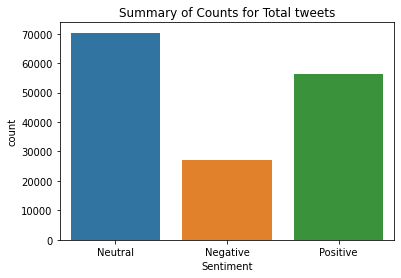

In [ ]:
#sns.countplot(df["Sentiment"],facecolor=(0, 0, 0, 0),linewidth=5,edgecolor=sns.color_palette("dark", 3))
sns.countplot(df["Sentiment"])
plt.title("Summary of Counts for Total tweets")

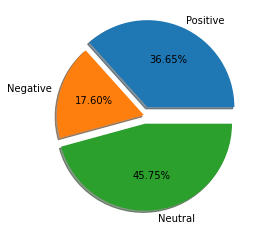

In [ ]:
# Piechart 
a=len(df[df["Sentiment"]=="Positive"])
b=len(df[df["Sentiment"]=="Negative"])
c=len(df[df["Sentiment"]=="Neutral"])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

In [ ]:
pip install vaderSentiment

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 125 kB 5.3 MB/s 


In [ ]:
# Function to analyze Sentiment using Vader

#from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

def analyze_sentiment_vader(tweet):
    analyzer = SentimentIntensityAnalyzer()
    analysis = analyzer.polarity_scores(tweet)
    # decide sentiment as positive, negative and neutral
    if analysis['compound'] >= 0.05 :
        return "Positive"
    elif analysis['compound'] <= - 0.05 :
        return "Negative"
    else :
        return "Neutral"

In [ ]:
# Call function to get the Sentiments using Vader

df["VaderSentiment"] = df["CleanTweet"].apply(lambda x : analyze_sentiment_vader(x))

,favorite_count,source,text,created_at,retweet_count,CleanTweet,Sentiment,FlairSentiment,VaderSentiment
0,0,Twitter Web App,b'...and ????\nwe should panic and not send th...,Sun Sep 06 04:03:19 +0000 2020,0,and we should panic and not send the kids to s...,Neutral,NEGATIVE,Negative
1,1,Twitter for iPhone,b'Please Chuck can you say \xe2\x80\x9cguaran...,Sun Sep 06 04:02:59 +0000 2020,0,chuck can you say coronavirus will last foreve...,Neutral,POSITIVE,Neutral
2,0,WordPress.com,b'Coronavirus Explained: What is coronavirus? ...,Sun Sep 06 04:03:29 +0000 2020,0,explained what is coronavirus bbc,Neutral,NEGATIVE,Neutral
3,3,Tweetbot for iΟS,b'@EricColumbus This article says they have 4....,Sun Sep 06 04:03:25 +0000 2020,1,ericcolumbus this article says they have 4 3 p...,Neutral,NEGATIVE,Positive
4,0,Twitter for iPad,b'@thedailybeast @DearAuntCrabby No surprise. ...,Sun Sep 06 04:03:08 +0000 2020,0,thedailybeast no surprise it is absurd to thin...,Negative,NEGATIVE,Negative


In [ ]:
df.tail(15)

,favorite_count,source,text,created_at,retweet_count,CleanTweet,Sentiment,FlairSentiment,VaderSentiment
153739,0,Twitter Web App,b'@mlkhattar @cmohry @BJP4Haryana so typical a...,Mon Sep 07 04:03:16 +0000 2020,0,mlkhattar so typical and shameful power obsess...,Negative,NEGATIVE,Negative
153740,6,Twitter Web App,b'COVID-19 test extends to all frontline worke...,Mon Sep 07 04:02:55 +0000 2020,0,19 test extends to all frontline workers,Neutral,POSITIVE,Positive
153741,0,Twitter for Android,"b'@DanRather tRump...""climate control is a hoa...",Mon Sep 07 04:03:01 +0000 2020,0,danrather trump climate control is a hoax trum...,Neutral,NEGATIVE,Negative
153742,9,Twitter for Android,b'Here is the retweet of the year... when exac...,Mon Sep 07 04:02:52 +0000 2020,13,is the retweet of the year when exactly is eno...,Neutral,NEGATIVE,Positive
153743,0,Twitter for Android,b'#RPSC_ACF_POSTPONE Please postpone RPSC ACF ...,Mon Sep 07 04:03:13 +0000 2020,0,rpsc acf postpone please postpone rpsc acf exa...,Negative,NEGATIVE,Negative
153744,4,TweetDeck,b'#JammuandKashmir authorities have admitted t...,Mon Sep 07 04:02:55 +0000 2020,2,jammuandkashmir authorities have admitted that...,Negative,NEGATIVE,Negative
153745,0,Twitter Web App,b'When they are vomiting up their insides or w...,Mon Sep 07 04:02:56 +0000 2020,0,they are vomiting up their insides or worse si...,Negative,NEGATIVE,Negative
153746,3,Hootsuite Inc.,b'COVID-19 crisis: Australia approves funding ...,Mon Sep 07 04:02:56 +0000 2020,2,19 crisis australia approves funding for two p...,Neutral,NEGATIVE,Negative
153747,5,Twitter for iPhone,b'#COVID19 statistics in South Africa. https:/...,Mon Sep 07 04:03:02 +0000 2020,4,covid19 statistics in south africa,Neutral,NEGATIVE,Neutral
153748,30,Echobox,b'Three schools in Teesside confirm coronaviru...,Mon Sep 07 04:02:56 +0000 2020,24,schools in teesside confirm coronavirus cases ...,Negative,NEGATIVE,Neutral


In [ ]:
df.head()

In [ ]:
df.to_csv("2020_Sep6_TextBlob-Vader-Flair-TweetSentimentDataset.csv",index=False)

In [ ]:
# Check Summary of Random Record for Vader
n = 150100
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet using Vader:\n",df['VaderSentiment'][n])

Original tweet:
 b'School reopening without adherence to COVID-19 protocols dangerous \xe2\x80\x94 ASUU https://t.co/I54sjNMjNQ'

Clean tweet:
 reopening without adherence to covid 19 protocols dangerous asuu

Sentiment of the tweet using Vader:
 Negative


In [ ]:
# Overall Summary for Vader

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["VaderSentiment"]=="Positive"])))
print("Total Negative Tweets are : {}".format(len(df[df["VaderSentiment"]=="Negative"])))
print("Total Neutral Tweets are : {}".format(len(df[df["VaderSentiment"]=="Neutral"])))

Total Tweets Extracted Are 152629
Total Positive Tweets are : 48993
Total Negative Tweets are : 46982
Total Neutral Tweets are : 56654


In [ ]:
df["VaderSentiment"].value_counts()

Neutral     56654
Positive    48993
Negative    46982
Name: VaderSentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

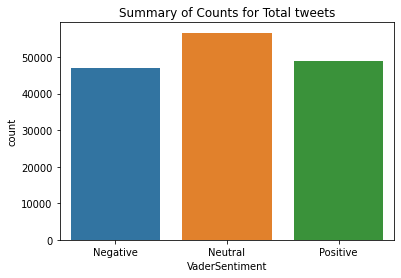

In [ ]:
sns.countplot(df["VaderSentiment"])
plt.title("Summary of Counts for Total tweets")

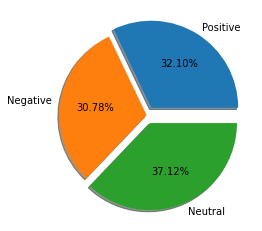

In [ ]:
# Piechart 
a=len(df[df["VaderSentiment"]=="Positive"])
b=len(df[df["VaderSentiment"]=="Negative"])
c=len(df[df["VaderSentiment"]=="Neutral"])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

In [ ]:
pip install flair

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 401 kB 5.3 MB/s 
     |████████████████████████████████| 1.2 MB 45.8 MB/s 
     |████████████████████████████████| 788 kB 56.7 MB/s 
     |████████████████████████████████| 120 kB 36.2 MB/s 
     |████████████████████████████████| 46 kB 3.8 MB/s 
     |████████████████████████████████| 19.7 MB 1.4 MB/s 
     |████████████████████████████████| 53 kB 1.7 MB/s 
     |████████████████████████████████| 4.7 MB 34.8 MB/s 
     |████████████████████████████████| 1.6 MB 49.6 MB/s 
     |████████████████████████████████| 981 kB 53.6 MB/s 
     |████████████████████████████████| 200 kB 19.8 MB/s 
     |████████████████████████████████| 62 kB 1.4 MB/s 
     |████████████████████████████████| 6.6 MB 36.2 MB/s 
  Created wheel for mpld3: filename=mpld3-0.3-py3-none-any.whl size=116702 sha256=72ca1ef0e888151af6dbb01a0b1b003fead1fc9439beb02fe3fb4bfcf28f56d9
  Store

In [ ]:
# Function to analyze Sentiment using Flair

from flair.models import TextClassifier
from flair.data import Sentence
classifier = TextClassifier.load('en-sentiment')
def analyze_sentiment_flair(tweet):
    sentence = Sentence(tweet)
    classifier.predict(sentence)
    #if(sentence.labels[0].value == 'POSITIVE'):
    #    return 'Positive'
    #else:
    #    return 'Negative'
    return sentence.labels[0].value

2022-09-14 04:31:39,680 loading file /root/.flair/models/sentiment-en-mix-distillbert_4.pt


In [ ]:
# Call function to get the Sentiments using Flair

df["FlairSentiment"] = df["CleanTweet"].apply(lambda x : analyze_sentiment_flair(x))
df.head(5)

,favorite_count,source,text,created_at,retweet_count,CleanTweet,Sentiment,FlairSentiment
0,0,Twitter Web App,b'...and ????\nwe should panic and not send th...,Sun Sep 06 04:03:19 +0000 2020,0,and we should panic and not send the kids to s...,Neutral,NEGATIVE
1,1,Twitter for iPhone,b'Please Chuck can you say \xe2\x80\x9cguaran...,Sun Sep 06 04:02:59 +0000 2020,0,chuck can you say coronavirus will last foreve...,Neutral,POSITIVE
2,0,WordPress.com,b'Coronavirus Explained: What is coronavirus? ...,Sun Sep 06 04:03:29 +0000 2020,0,explained what is coronavirus bbc,Neutral,NEGATIVE
3,3,Tweetbot for iΟS,b'@EricColumbus This article says they have 4....,Sun Sep 06 04:03:25 +0000 2020,1,ericcolumbus this article says they have 4 3 p...,Neutral,NEGATIVE
4,0,Twitter for iPad,b'@thedailybeast @DearAuntCrabby No surprise. ...,Sun Sep 06 04:03:08 +0000 2020,0,thedailybeast no surprise it is absurd to thin...,Negative,NEGATIVE


In [ ]:
df.rename(columns={'Sentiment': 'TextBlobSentiment'},inplace=True)

In [ ]:
df.head()

,favorite_count,source,text,created_at,retweet_count,CleanTweet,TextBlobSentiment,FlairSentiment,VaderSentiment
0,0,Twitter Web App,b'...and ????\nwe should panic and not send th...,Sun Sep 06 04:03:19 +0000 2020,0,and we should panic and not send the kids to s...,Neutral,NEGATIVE,Negative
1,1,Twitter for iPhone,b'Please Chuck can you say \xe2\x80\x9cguaran...,Sun Sep 06 04:02:59 +0000 2020,0,chuck can you say coronavirus will last foreve...,Neutral,POSITIVE,Neutral
2,0,WordPress.com,b'Coronavirus Explained: What is coronavirus? ...,Sun Sep 06 04:03:29 +0000 2020,0,explained what is coronavirus bbc,Neutral,NEGATIVE,Neutral
3,3,Tweetbot for iΟS,b'@EricColumbus This article says they have 4....,Sun Sep 06 04:03:25 +0000 2020,1,ericcolumbus this article says they have 4 3 p...,Neutral,NEGATIVE,Positive
4,0,Twitter for iPad,b'@thedailybeast @DearAuntCrabby No surprise. ...,Sun Sep 06 04:03:08 +0000 2020,0,thedailybeast no surprise it is absurd to thin...,Negative,NEGATIVE,Negative


In [ ]:
df.to_csv("TextBlob-Vader-Flair-TweetSentimentDataset.csv",index=False)

In [ ]:
# Check Summary of Random Record for Flair
n = 153000
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet using Flair:\n",df['FlairSentiment'][n])

Original tweet:
 b'I\xe2\x80\x99ll happily pay for the hotel to support the struggling tourism sector, &amp; for the many many COVID-19 tests &amp; respe\xe2\x80\xa6 https://t.co/cy0mAk2suy'

Clean tweet:
 happily pay for the hotel to support the struggling tourism sector amp for the many many covid 19 tests amp respe

Sentiment of the tweet using Flair:
 POSITIVE


In [ ]:
# Overall Summary for Flair

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["FlairSentiment"]=="POSITIVE"])))
print("Total Negative Tweets are : {}".format(len(df[df["FlairSentiment"]=="NEGATIVE"])))
print("Total Neutral Tweets are : {}".format(len(df[df["FlairSentiment"]=="NEUTRAL"])))

Total Tweets Extracted Are 152629
Total Positive Tweets are : 58521
Total Negative Tweets are : 94108
Total Neutral Tweets are : 0


In [ ]:
df["FlairSentiment"].value_counts()

NEGATIVE    94108
POSITIVE    58521
Name: FlairSentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

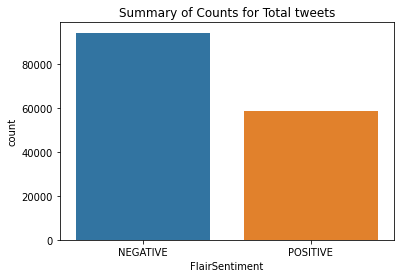

In [ ]:
sns.countplot(df["FlairSentiment"])
plt.title("Summary of Counts for Total tweets")

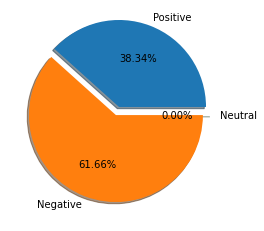

In [ ]:
# Piechart 

a=len(df[df["FlairSentiment"]=="POSITIVE"])
b=len(df[df["FlairSentiment"]=="NEGATIVE"])
c=len(df[df["FlairSentiment"]=="NEUTRAL"])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

In [ ]:
# Combine all reviews into one big text and create a Cloud to see which Words are most common in these Tweets.

text = " ".join(review for review in df.CleanTweet)
print ("There are {} words in the combination of all review.".format(len(text)))


# Create stopword list:
stopwords = set(STOPWORDS)
Topic= "corona covid covid-19 covid19 coronavirus virus amp people case cases xe2 one don t re s c u xf0"
text_newALL = prepCloud(text,Topic)


# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords,max_words=800,max_font_size=70).generate(text_newALL)

plt.figure(figsize=(20,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("The most frequently used words when searching for {}".format("Covid"),)
plt.axis("off")
plt.show()

In [ ]:
# Combine POSITIVE reviews into one big text and create a Cloud to see which Words are most common in these Tweets.

text_positive = " ".join(review for review in df[df["Sentiment"]=="Positive"].CleanTweet)
print ("There are {} words in the combination of all review.".format(len(text)))


# Create stopword list:
stopwords = set(STOPWORDS)
Topic= "corona covid covid-19 covid19 coronavirus virus amp people case cases xe2 one don t re s c u xf0"
text_new_positive = prepCloud(text_positive,Topic)


# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords,max_words=800,max_font_size=70).generate(text_new_positive)

plt.figure(figsize=(20,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("The most frequently used words in positive sentiment tweets")
plt.axis("off")
plt.show()

In [ ]:
# Combine Negative reviews into one big text and create a Cloud to see which Words are most common in these Tweets.

text_negative = " ".join(review for review in df[df["Sentiment"]=="Negative"].CleanTweet)
print ("There are {} words in the combination of all review.".format(len(text)))


# Create stopword list:
stopwords = set(STOPWORDS)
Topic= "corona covid covid-19 covid19 coronavirus virus amp people case cases xe2 one don t re s c u xf0"
text_new_negative = prepCloud(text_negative,Topic)

# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords,max_words=800,max_font_size=70).generate(text_new_negative)

# Display the generated image:
# the matplotlib way:


plt.figure(figsize=(20,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("The most frequently used words in negative sentiment tweets")
plt.axis("off")
plt.show()